In [1]:
import sys
sys.path.append('../')
from qufold import MiyazawaJerniganInteraction, Peptide, RandomInteraction, ProteinFoldingProblem, PenaltyParameters
from qiskit.utils import algorithm_globals, QuantumInstance
from qiskit.circuit.library import RealAmplitudes
from qiskit.algorithms.optimizers import COBYLA
from qiskit.algorithms.minimum_eigensolvers import SamplingVQE
from qiskit.primitives import Sampler
import matplotlib.pyplot as plt
import os
import numpy as np

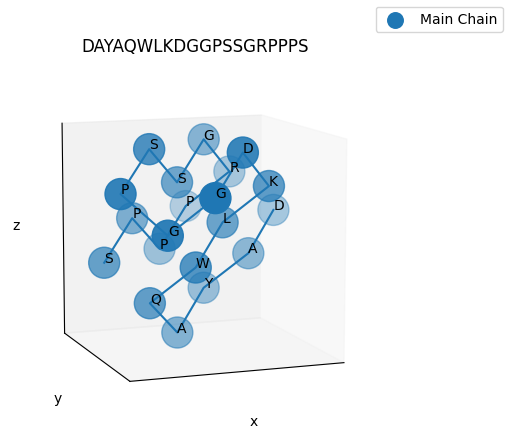

In [2]:

main_seq = 'DAYAQWLKDGGPSSGRPPPS'
side_chains = [""] * len(main_seq)
mj_interaction = MiyazawaJerniganInteraction()
penalty_back = 0
penalty_chiral = 10
penalty_1 = 10
penalty_terms = PenaltyParameters(penalty_chiral, penalty_back, penalty_1)
peptide = Peptide(main_seq, side_chains)
protein_folding_problem = ProteinFoldingProblem(peptide, mj_interaction, penalty_terms)
qubit_op = protein_folding_problem.qubit_op()
result = protein_folding_problem.interpret_bitstring("0100000000000000000000010000011000000000000100000000000100100000100110000110011011001001001000010")


with open("results.txt", "w+") as bitstring_file:
    bitstring_file.write("{}\n{}\n".format("The bitstring representing the shape of the protein during optimization is: ", result.turn_sequence))
    bitstring_file.write("{}\n{}\n".format("The expanded expression is:", result.get_result_binary_vector()))
    bitstring_file.write("{}\n".format(f"The folded protein's main sequence of turns is: {result.protein_shape_decoder.main_turns}"))
    bitstring_file.write("{}\n".format(f"and the side turn sequences are: {result.protein_shape_decoder.side_turns}"))


## if you do this below, it will have the short bond lengths, so no need to save this
#result.save_xyz_file(replace=True, name= "test_trpcage")

##

import matplotlib.pyplot as plt
fig = result.get_figure(title=main_seq, ticks=False, grid=True)
fig.get_axes()[0].view_init(10, 70)
#fig.show()
fig.savefig(main_seq + ".png", dpi=800,transparent=False)


In [3]:

## convert this xyzdata into one with proper bond lengths
new_positions = []

for realbonds in result.protein_shape_file_gen.get_xyz_data():
    cp = [realbonds[0]]
    for element_index in range(1,len(realbonds)):
        cp.append(str(float(realbonds[element_index])*3.8))
    cp = np.array(cp)
    new_positions.append(cp)
new_positions = np.array(new_positions)
print(new_positions)


[['D' '0.0' '0.0' '0.0']
 ['A' '2.193931022920578' '2.193931022920578' '-2.193931022920578']
 ['Y' '4.387862045841156' '0.0' '-4.387862045841156']
 ['A' '6.581793068761734' '2.193931022920578' '-6.581793068761734']
 ['Q' '8.775724091682312' '4.387862045841156' '-4.387862045841157']
 ['W' '6.581793068761734' '6.581793068761734' '-2.193931022920579']
 ['L' '4.387862045841157' '4.387862045841157' '-8.437694987151189e-16']
 ['K' '2.193931022920579' '6.581793068761734' '2.193931022920577']
 ['D' '4.387862045841157' '8.775724091682312' '4.387862045841155']
 ['G' '6.581793068761734' '10.96965511460289' '2.193931022920577']
 ['G' '8.775724091682312' '8.775724091682312' '-8.437694987151189e-16']
 ['P' '10.96965511460289' '6.581793068761734' '2.193931022920577']
 ['S' '8.775724091682312' '4.387862045841157' '4.387862045841155']
 ['S' '6.581793068761734' '2.193931022920579' '2.193931022920577']
 ['G' '4.387862045841157' '8.437694987151189e-16' '4.387862045841155']
 ['R' '2.193931022920579' '-2.19

In [4]:
## generate a new xyz file with the real bond lengths
xyzfile = os.path.join(main_seq + ".xyz")
data = new_positions
number_of_particles = data.shape[0]
header = f"{number_of_particles}\n"
np.savetxt(
    fname=xyzfile,
    header=header,
    X=data,
    delimiter=" ",
    fmt="%s",
    comments="",
    )

In [5]:
from xyz2pdb import xyz2pdb
qiskit_xyz = xyz2pdb.load_xyz_data(xyzfile)
##print(qiskit_xyz)
xyz2pdb.build_pdb(qiskit_xyz, alpha_c_trace=True, replace=True, out_pdb_name=main_seq +"_ca")
xyz2pdb.build_pdb(qiskit_xyz, hetero_atoms=True, replace=True, out_pdb_name=main_seq +"_hetatm")